In [1]:
from pathlib import Path

from prismadv.data_models import ConstraintsWithSources
from prismadv.data_models.config import PrismaDVConfig
from workflow.utils.results_analysis import collect_results
from workflow.utils.results_analysis import format_results_latex, build_confusion_matrices

In [2]:
dataset_name_options = ["students", "hr_analytics", "sleep_health", "IPL_win_prediction", "imdb"]
model_order = ["gpt-5"]
unique_subset_cols = [
    "llm_name", "llm_temperature", "use_async",
    "dataset_name", "subtask_name",
    "processed_data_label", "script_name", "is_clean"
]

In [3]:
def meta_extractor_prismadv(constraint_file: Path, raw: dict) -> dict:
    prismadv_config = PrismaDVConfig.from_dict(raw["prismadv_config"])
    return {
        "llm_name": prismadv_config.llm.model_name,
        "llm_temperature": prismadv_config.llm.temperature,
        "use_async": prismadv_config.model.use_async,
        "timestamp": constraint_file.stem.split("--")[-1],
    }


def constraints_parser_prismadv(raw: dict):
    return ConstraintsWithSources.from_dict({"constraints": raw["constraints"]})


def validation_kwargs_prismadv():
    # supply the toggle used in your original snippet
    return {"constraints_on_single_column_only": False}


df_all_unique = collect_results(
    dataset_name_options=dataset_name_options,
    unique_subset_cols=unique_subset_cols,
    constraint_glob="prismadv_wo_assumption_before_post--*.yaml",
    row_meta_extractor=meta_extractor_prismadv,
    constraints_parser=constraints_parser_prismadv,
    validation_check_kwargs_fn=validation_kwargs_prismadv,
    model_order=model_order,  # optional filter
)

In [4]:
confusion_matrices_df = build_confusion_matrices(df_all_unique)

In [5]:
latex_output = format_results_latex(
    confusion_matrex_df=confusion_matrices_df,
    dataset_name_options=dataset_name_options,
    model_order=model_order,
    decimals=2,
    model_label_prefix="w/o Assumption",
    include_overall=True
)
print(latex_output)

%% === Dataset: students ===
& \texttt{w/o Assumption [gpt-5]} & 54.5 & 0.0 & 129 & 2 & 30 & 89 & 59.17\% & 98.47\% & 73.93\% \\
%% === Dataset: hr_analytics ===
& \texttt{w/o Assumption [gpt-5]} & 72.2 & 0.0 & 160 & 7 & 25 & 108 & 59.70\% & 95.81\% & 73.56\% \\
%% === Dataset: sleep_health ===
& \texttt{w/o Assumption [gpt-5]} & 50.5 & 0.0 & 170 & 3 & 47 & 105 & 61.82\% & 98.27\% & 75.89\% \\
%% === Dataset: IPL_win_prediction ===
& \texttt{w/o Assumption [gpt-5]} & 78.3 & 0.0 & 185 & 24 & 114 & 52 & 78.06\% & 88.52\% & 82.96\% \\
%% === Dataset: imdb ===
& \texttt{w/o Assumption [gpt-5]} & 50.7 & 0.0 & 138 & 9 & 41 & 62 & 69.00\% & 93.88\% & 79.54\% \\

%% === Overall (All Datasets Combined) ===
& \texttt{w/o Assumption [gpt-5]} & 61.2 & 0.0 & 782 & 45 & 257 & 416 & 65.55\% & 94.99\% & 77.18\% \\


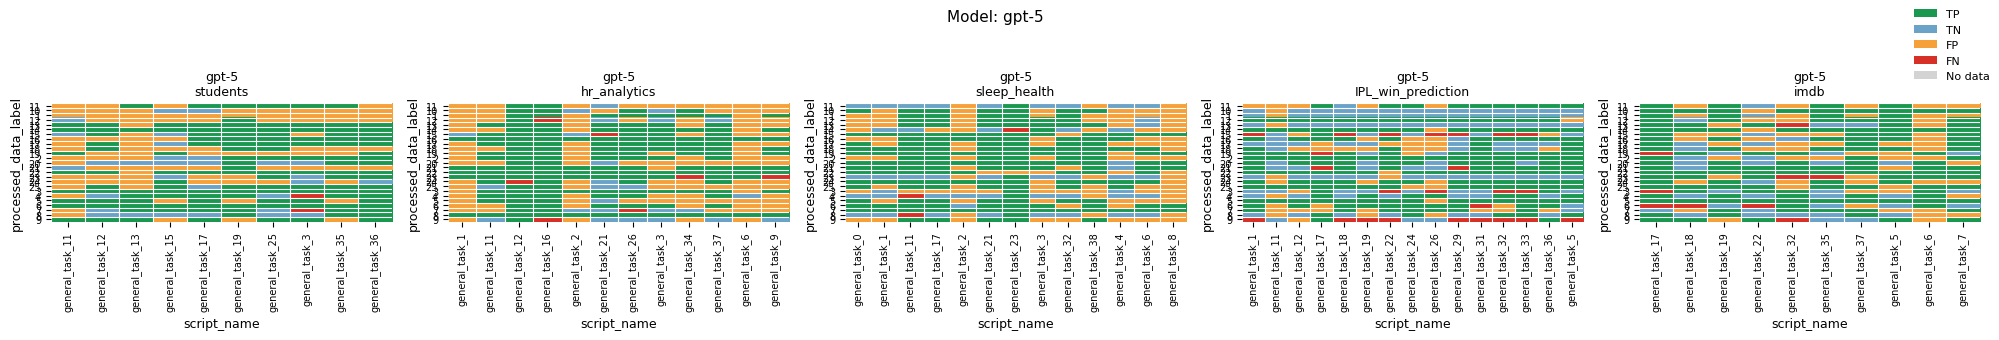

In [6]:
from workflow.utils.results_analysis import build_correct_grids, plot_correct_grids

grids = build_correct_grids(df_all_unique, dataset_name_options, threshold=0.5)
plot_correct_grids(grids, model_order=model_order, dataset_name_options=dataset_name_options)